Import Library

In [1]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

Load Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv("/content/drive/MyDrive/SKRIPSI MANTAP/data sosmed/Instagram/ig_pseudo.csv")

df = df[["ig_clean", "label_sentimen", "confidence_score"]]

df = df.dropna().reset_index(drop=True)
df = df[df["confidence_score"] > 0.8].reset_index(drop=True)

print(f"Jumlah data setelah filter: {len(df):,}")
print(df["label_sentimen"].value_counts())

Jumlah data setelah filter: 19,966
label_sentimen
negative    12456
neutral      4129
positive     3381
Name: count, dtype: int64


Encode Label

In [4]:
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["label_sentimen"])

# Tampilkan mapping label
print("Mapping Label:")
for label, encoded in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"{label} -> {encoded}")

# Tampilkan beberapa data hasil encoding
print("\nContoh Hasil Encoding:")
print(df[["label_sentimen", "label"]].head(5))

Mapping Label:
negative -> 0
neutral -> 1
positive -> 2

Contoh Hasil Encoding:
  label_sentimen  label
0       positive      2
1       positive      2
2        neutral      1
3       negative      0
4        neutral      1


Train Test Split

In [5]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

In [6]:
#split data train jadi train dan validation

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

Load IndoBERTweet

In [7]:
MODEL_NAME = "indolem/indobertweet-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

bert = AutoModel.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/1.10k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/235k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  445MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
bert.eval()

for param in bert.parameters():
    param.requires_grad = False

Dataset

In [9]:
class SentimentDataset(Dataset):

    def __init__(self, dataframe):

        self.texts = dataframe["ig_clean"].tolist()
        self.labels = dataframe["label"].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        return self.texts[idx], self.labels[idx]

Embedding

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

bert = bert.to(device)

MAX_LENGTH = 50

def collate_fn(batch):

    texts = [x[0] for x in batch]

    labels = torch.tensor(
        [x[1] for x in batch],
        dtype=torch.long
    )

    encoded = tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

    encoded = {
        k:v.to(device)
        for k,v in encoded.items()
    }

    with torch.no_grad():

        embeddings = bert(**encoded).last_hidden_state

    return embeddings, labels.to(device)

model.safetensors: reconstructing file:   0%|          |  0.00B /  445MB            

model.safetensors: downloading bytes:           |  0.00B            

Data Loader

In [11]:
train_dataset = SentimentDataset(train_df)
val_dataset = SentimentDataset(val_df)
test_dataset = SentimentDataset(test_df)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)

BiLSTM

In [12]:
class BiLSTMClassifier(nn.Module):

    def __init__(self):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=768,
            hidden_size=128,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(256,3)

    def forward(self,x):

        output,(hidden,cell)=self.lstm(x)

        hidden=torch.cat(
            (hidden[-2],hidden[-1]),
            dim=1
        )

        hidden=self.dropout(hidden)

        return self.fc(hidden)

In [13]:
# 2. Membuat model
model = BiLSTMClassifier().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=2e-4
)

# Menyimpan history training
train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

Training

In [14]:
import copy

best_epoch = 0
best_val_loss = float("inf")

best_model = None

patience = 3          # berhenti jika 3 epoch berturut-turut tidak membaik
counter = 0

In [15]:
EPOCHS = 10

for epoch in range(EPOCHS):

    # ===========================
    # Training
    # ===========================
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for embeddings, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(embeddings)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ===========================
    # Validation
    # ===========================
    model.eval()

    running_val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for embeddings, labels in val_loader:

            outputs = model(embeddings)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        val_loss = running_val_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    # ===========================
    # Early Stopping
    # ===========================
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch + 1

        best_model = copy.deepcopy(model.state_dict())

        counter = 0

        print("Validation loss membaik, model disimpan.")

    else:

        counter += 1

        print(f"Tidak ada peningkatan ({counter}/{patience})")

        if counter >= patience:
            print(f"\nEarly stopping pada epoch {epoch+1}")
            break

Epoch [1/10] Train Loss: 0.4503 | Train Acc: 0.8228 | Val Loss: 0.2844 | Val Acc: 0.8951
Validation loss membaik, model disimpan.
Epoch [2/10] Train Loss: 0.2172 | Train Acc: 0.9199 | Val Loss: 0.2645 | Val Acc: 0.8920
Validation loss membaik, model disimpan.
Epoch [3/10] Train Loss: 0.1459 | Train Acc: 0.9500 | Val Loss: 0.2275 | Val Acc: 0.9177
Validation loss membaik, model disimpan.
Epoch [4/10] Train Loss: 0.1010 | Train Acc: 0.9659 | Val Loss: 0.2329 | Val Acc: 0.9161
Tidak ada peningkatan (1/3)
Epoch [5/10] Train Loss: 0.0637 | Train Acc: 0.9796 | Val Loss: 0.2396 | Val Acc: 0.9199
Tidak ada peningkatan (2/3)
Epoch [6/10] Train Loss: 0.0424 | Train Acc: 0.9876 | Val Loss: 0.2616 | Val Acc: 0.9243
Tidak ada peningkatan (3/3)

Early stopping pada epoch 6


In [16]:
print("="*50)
print(f"Epoch terbaik      : {best_epoch}")
print(f"Validation Loss    : {best_val_loss:.4f}")
print("="*50)

# Mengembalikan model terbaik
model.load_state_dict(best_model)

Epoch terbaik      : 3
Validation Loss    : 0.2275


<All keys matched successfully>

Test

In [17]:
model.eval()

predictions = []
actuals = []

with torch.no_grad():

    for embeddings, labels in test_loader:

        outputs = model(embeddings)

        pred = torch.argmax(outputs, dim=1)

        predictions.extend(pred.cpu().numpy())
        actuals.extend(labels.cpu().numpy())

Evaluasi

In [18]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

acc = accuracy_score(actuals, predictions)
prec = precision_score(actuals, predictions, average="weighted")
rec = recall_score(actuals, predictions, average="weighted")
f1 = f1_score(actuals, predictions, average="weighted")

print("Accuracy :", round(acc,4))
print("Precision:", round(prec,4))
print("Recall   :", round(rec,4))
print("F1 Score :", round(f1,4))

Accuracy : 0.9236
Precision: 0.9231
Recall   : 0.9236
F1 Score : 0.9226


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print(classification_report(actuals, predictions))

cm = confusion_matrix(actuals, predictions)

print(cm)

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      2492
           1       0.93      0.87      0.90       826
           2       0.90      0.82      0.86       676

    accuracy                           0.92      3994
   macro avg       0.92      0.89      0.90      3994
weighted avg       0.92      0.92      0.92      3994

[[2418   35   39]
 [  83  719   24]
 [ 102   22  552]]


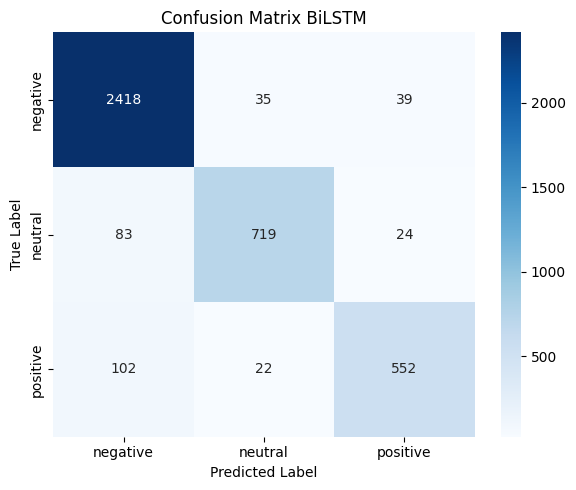

In [20]:
class_names = label_encoder.classes_

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix BiLSTM")

plt.tight_layout()
plt.show()

Grafik Akurasi

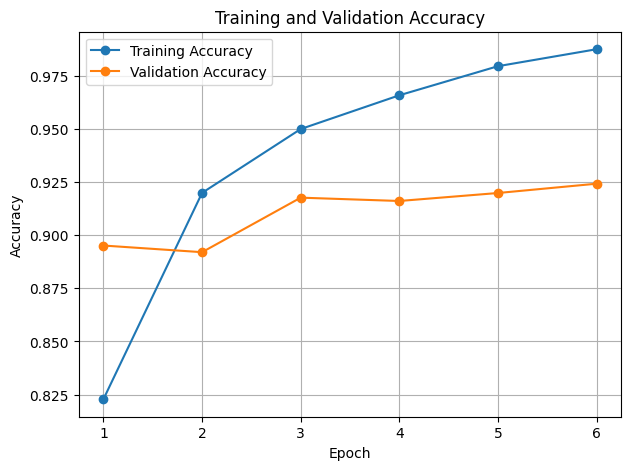

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(
    range(1, len(train_accuracies)+1),
    train_accuracies,
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    range(1, len(val_accuracies)+1),
    val_accuracies,
    marker='o',
    label='Validation Accuracy'
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(range(1, len(train_accuracies)+1))
plt.grid(True)
plt.legend()

plt.show()

Grafik Loss

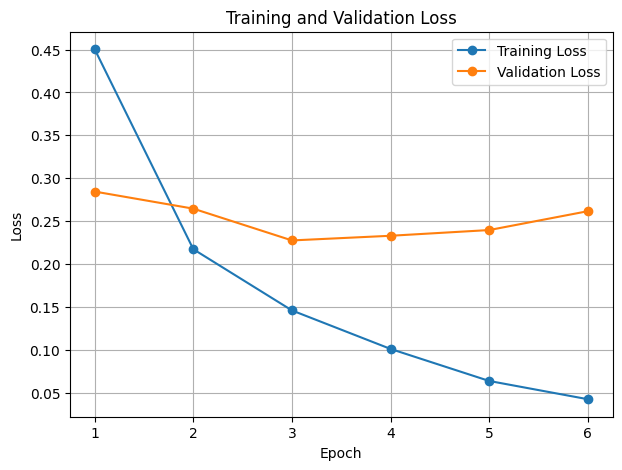

In [22]:
plt.figure(figsize=(7,5))

plt.plot(
    range(1, len(train_losses)+1),
    train_losses,
    marker='o',
    label='Training Loss'
)

plt.plot(
    range(1, len(val_losses)+1),
    val_losses,
    marker='o',
    label='Validation Loss'
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(1, len(train_losses)+1))
plt.grid(True)
plt.legend()

plt.show()